# Kappa refinement: organization and connectivity

Follow-up at $\widetilde\kappa=2.5$, $\lambda=1$, $N=1000$, up to $t=1500$.
Compare elongated and round populations across density, time windows, and overlap thresholds.
Available densities and seeds are detected automatically, including $\rho=0.75$ and additional realizations when their completed data are added.

Place this notebook in `preliminar/kappa/refinement/`, beside `processed/` and `ovito/`. Run cells in order.
Dependencies: NumPy, pandas, PyArrow, SciPy, Matplotlib and IPython.

Connectivity criteria are **postprocessing choices**, not changes to the simulation. Ensemble means give each realization equal weight. Temporal smoothing is only a display option; all summaries use unsmoothed observations.

## 1. Settings and data validation

The archive contains no launch script. Time conversion and output cadence remain explicit inputs.
Reprocess the complete dataset into one Parquet per observable after the new runs finish, and add their snapshots to `ovito/`.
Run counts may differ across densities; they are displayed and exported. Every included run must cover the requested time interval completely.

In [1]:
from pathlib import Path
from itertools import product
from functools import lru_cache
import json
import re
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

DATA_DIR = Path(".")
PROCESSED_DIR = DATA_DIR / "processed"
SNAPSHOT_DIR = DATA_DIR / "ovito"
FIGURE_DIR = DATA_DIR / "figures"
TABLE_DIR = DATA_DIR / "analysis_tables"
for directory in (FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DELTA_T = 0.05
FINAL_STEP = 30_000
OUTPUT_STEP = 100
FINAL_TIME = FINAL_STEP * DELTA_T
# None includes every density available for the selected kappa, lambda and N.
DENSITIES_TO_USE = None
EXPECTED_N = 1000
KAPPA = 2.5
LAMBDA_CORE = 1.0
RUN_KEYS = ["lambda_core", "kappa", "rho", "seed"]
TIME_WINDOWS = [(250, 500), (750, 1000), (1250, 1500)]
XI_CUT = np.exp(-1)
XI_SAFE = 0.8
RANGE_FACTORS = [1.0, 1.1, 1.2]
POLAR_ANGLE_DEG = 45.0
# Analyze all saved frames by default. Use a multiple of OUTPUT_STEP for a preview.
CONNECTIVITY_STEP = 100
RECOMPUTE_CONNECTIVITY = False
SAVE_FIGURES = True
SAVE_PDF = False
MAP_DENSITIES = [0.70, 0.84, 0.90]
MAP_STEP = FINAL_STEP

def save_figure(fig, stem):
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=180, bbox_inches="tight")
        if SAVE_PDF:
            fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")

def finish_figure(fig, stem):
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)

# Centered moving mean, in physical simulation-time units (None or 0 disables it).
CLUSTER_SMOOTHING_TIME = 25.0
SHOW_RAW_CLUSTER_CURVES = True
# Maps can be expensive to render with many seeds. None includes all available seeds.
MAP_SEEDS = None
PLOT_COMPONENT_MAPS = True
PLOT_ROUND_COMPONENT_MAPS = False
POPULATION_NAMES = {"elongated": "Elongated", "round": "Round"}
POPULATION_SYMBOLS = {"elongated": "E", "round": "R"}
GRAPH_CHOICES = [("elongated", False), ("elongated", True), ("round", False)]
RANGE_COLORS = dict(zip(RANGE_FACTORS, plt.get_cmap("tab10").colors))

In [2]:
tables = {}
for name in ["order_parameters", "motion", "deformation", "overlap"]:
    frame = pd.read_parquet(PROCESSED_DIR / name / f"{name}.parquet")
    selected = (np.isclose(frame.kappa, KAPPA)
                & np.isclose(frame.lambda_core, LAMBDA_CORE)
                & frame.actual_N.eq(EXPECTED_N) & frame.step.le(FINAL_STEP))
    if DENSITIES_TO_USE is not None:
        selected &= np.isclose(frame.rho.to_numpy()[:, None], DENSITIES_TO_USE).any(axis=1)
    frame = frame.loc[selected].copy()
    assert not frame.empty, f"No selected data in {name}."
    frame["time"] = frame["step"] * DELTA_T
    tables[name] = frame.sort_values(RUN_KEYS + ["step"]).reset_index(drop=True)
order_parameters, motion, deformation, overlap = [tables[n] for n in
    ["order_parameters", "motion", "deformation", "overlap"]]
DENSITIES = sorted(order_parameters.rho.unique().tolist())
SEEDS = sorted(order_parameters.seed.unique().tolist())
seed_palette = plt.get_cmap("tab10" if len(SEEDS) <= 10 else "tab20").colors
SEED_COLORS = {seed: seed_palette[i % len(seed_palette)] for i, seed in enumerate(SEEDS)}
expected_runs = set(order_parameters[RUN_KEYS].itertuples(index=False, name=None))
checks = []
for name, frame in tables.items():
    observed = set(frame[RUN_KEYS].itertuples(index=False, name=None))
    first = 0 if name in ["order_parameters", "motion"] else OUTPUT_STEP
    expected_steps = np.arange(first, FINAL_STEP + 1, OUTPUT_STEP)
    checks.append(dict(dataset=name, runs=len(observed),
        missing_runs=len(expected_runs-observed), unexpected_runs=len(observed-expected_runs),
        duplicates=int(frame.duplicated(RUN_KEYS+["step"]).sum()),
        incomplete_runs=sum(not np.array_equal(g.step.to_numpy(), expected_steps)
                            for _, g in frame.groupby(RUN_KEYS))))
checks = pd.DataFrame(checks)
display(checks)
assert checks[["missing_runs", "unexpected_runs", "duplicates", "incomplete_runs"]].eq(0).all().all(), (
    "Some data are missing, duplicated, or incomplete. Finish/reprocess these runs before comparing them.")
if DENSITIES_TO_USE is not None:
    assert all(np.isclose(DENSITIES, rho).any() for rho in DENSITIES_TO_USE)
for weighted, raw in [("polar_2", "polar"), ("nematic_2", "nematic")]:
    assert np.allclose(order_parameters[weighted], order_parameters.fraction_elongated * order_parameters[raw], atol=2e-6)
assert overlap.max_normalized_overlap.between(0, 1+1e-10).all()
accepted = deformation.loc[deformation.contraction_events > 0, "max_contraction_accepted_overlap"]
assert accepted.le(XI_SAFE+1e-10).all()
run_counts = (order_parameters[RUN_KEYS].drop_duplicates().groupby("rho", as_index=False)
              .agg(n_realizations=("seed", "nunique")))
display(run_counts)
display(pd.DataFrame({"realization": range(1, len(SEEDS)+1), "seed": SEEDS}))

def seed_handles(seeds=None):
    seeds = SEEDS if seeds is None else seeds
    return [Line2D([0], [0], color=SEED_COLORS[s], label=f"Realization {SEEDS.index(s)+1}")
            for s in seeds]

,dataset,runs,missing_runs,unexpected_runs,duplicates,incomplete_runs
0,order_parameters,20,0,0,0,0
1,motion,20,0,0,0,0
2,deformation,20,0,0,0,0
3,overlap,20,0,0,0,0


,rho,n_realizations
0,0.70,4
1,0.80,4
2,0.84,4
3,0.88,4
4,0.90,4


,realization,seed
0,1,853827592514924
1,2,993068073743470
2,3,1052030010736714
3,4,1099062448631258


In [3]:
pattern = re.compile(r"_density=(?P<rho>[0-9.]+)_force=.*?_k=(?P<kappa>[0-9.]+)_.*?_lambda_core=(?P<lambda_core>[0-9.]+)_.*?_rng_seed=(?P<seed>\d+)\.(?P<step>\d+)$")
snapshot_paths = {}
for path in sorted(SNAPSHOT_DIR.rglob("*")):
    match = pattern.search(path.name) if path.is_file() else None
    if match is None:
        continue
    d = match.groupdict()
    key = (float(d["lambda_core"]), float(d["kappa"]), float(d["rho"]), int(d["seed"]), int(d["step"]))
    if key[:-1] not in expected_runs or key[-1] > FINAL_STEP:
        continue
    if key in snapshot_paths:
        raise ValueError(f"Duplicate snapshot: {key}")
    snapshot_paths[key] = path
expected_snapshots = {(*run, step) for run in expected_runs
                      for step in range(0, FINAL_STEP+1, OUTPUT_STEP)}
assert set(snapshot_paths) == expected_snapshots, (
    f"Missing: {len(expected_snapshots-set(snapshot_paths))}; "
    f"unexpected: {len(set(snapshot_paths)-expected_snapshots)}")
print(f"Validated {len(snapshot_paths)} snapshots across {len(expected_runs)} runs.")

Validated 6020 snapshots across 20 runs.


## 2. Final configurations

Colors encode the full polar angle; round cells are gray. Periodic copies are drawn at box edges. All panels show the complete box, whose physical size changes with density.

In [4]:
from matplotlib.collections import EllipseCollection
from matplotlib.colors import ListedColormap, Normalize, hsv_to_rgb
from matplotlib.patches import Patch

# Orientation colors shared by every figure
hue = np.linspace(0, 1, 1024)
hsv_colors = np.column_stack([
    hue,
    np.full_like(hue, 0.75),
    np.full_like(hue, 0.90),
])

ORIENTATION_CMAP = ListedColormap(
    hsv_to_rgb(hsv_colors),
    name="orientation_hsv",
)
ORIENTATION_NORM = Normalize(0, 2 * np.pi)
ROUND_COLOR = "0.80"


@lru_cache(maxsize=32)
def read_snapshot(path):
    """Read positions, semi-axes, orientations, and box dimensions."""
    with path.open() as stream:
        number_of_cells = int(stream.readline())
        header = stream.readline()


        expected_schema = "Properties=species:S:1:pos:R:3:aspherical_shape:R:3:orientation:R:4:Color:R:1"
        if expected_schema not in header:
            raise ValueError(f"Unexpected OVITO schema: {path}")

        lattice_match = re.search(r'Lattice="([^"]+)"', header)
        if lattice_match is None:
            raise ValueError(f"Missing box dimensions in {path}")

        lattice = np.fromstring(
            lattice_match.group(1),
            sep=" ",
        ).reshape(3, 3)

        values = np.loadtxt(
            stream,
            usecols=range(1, 12),
            ndmin=2,
        )

    if len(values) != number_of_cells:
        raise ValueError(f"Inconsistent cell count in {path}")

    if not np.allclose(lattice, np.diag(np.diag(lattice))):
        raise ValueError(f"Only orthorhombic boxes are supported: {path}")
    box = np.array([lattice[0, 0], lattice[1, 1]])
    if not np.all(box > 0) or not np.isfinite(values).all():
        raise ValueError(f"Invalid box or nonfinite snapshot data: {path}")
    if np.any(values[:, 3:5] <= 0):
        raise ValueError(f"Invalid semi-axes: {path}")

    # Planar rotations are stored as quaternions (x, y, z, w)
    phi = np.mod(
        2 * np.arctan2(values[:, 8], values[:, 9]),
        2 * np.pi,
    )

    return {
        "positions": values[:, :2] % box,
        "major": values[:, 3],
        "minor": values[:, 4],
        "phi": phi,
        "box": box,
    }


def draw_snapshot(ax, snapshot, facecolors=None, annotation=None):
    """Draw one configuration, including periodic boundary copies."""
    positions = snapshot["positions"]
    major = snapshot["major"]
    minor = snapshot["minor"]
    phi = snapshot["phi"]
    box = snapshot["box"]

    is_round = np.isclose(major / minor, 1.0)

    colors = ORIENTATION_CMAP(ORIENTATION_NORM(phi))
    colors[is_round] = plt.matplotlib.colors.to_rgba(ROUND_COLOR)
    if facecolors is not None:
        colors = np.asarray(facecolors)

    # Bounding-box half-widths of each rotated ellipse
    extent_x = np.sqrt(
        (major * np.cos(phi))**2
        + (minor * np.sin(phi))**2
    )
    extent_y = np.sqrt(
        (major * np.sin(phi))**2
        + (minor * np.cos(phi))**2
    )

    for shift_x, shift_y in product(
        [-box[0], 0, box[0]],
        [-box[1], 0, box[1]],
    ):
        shifted = positions + np.array([shift_x, shift_y])

        visible = (
            (shifted[:, 0] + extent_x >= 0)
            & (shifted[:, 0] - extent_x <= box[0])
            & (shifted[:, 1] + extent_y >= 0)
            & (shifted[:, 1] - extent_y <= box[1])
        )

        if not visible.any():
            continue

        collection = EllipseCollection(
            widths=2 * major[visible],
            heights=2 * minor[visible],
            angles=np.degrees(phi[visible]),
            units="xy",
            offsets=shifted[visible],
            transOffset=ax.transData,
            facecolors=colors[visible],
            edgecolors="0.25",
            linewidths=0.20,
            rasterized=True,
        )
        ax.add_collection(collection)

    ax.set(
        xlim=(0, box[0]),
        ylim=(0, box[1]),
        aspect="equal",
        xticks=[],
        yticks=[],
    )

    ax.text(
        0.03,
        0.97,
        (rf"$f_E={np.mean(~is_round):.2f}$" if annotation is None else annotation),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.8,
            "pad": 1.5,
        },
    )


def add_orientation_wheel(fig):
    """Add a circular legend using the same orientation mapping."""
    ax = fig.add_axes(
        [0.875, 0.90, 0.065, 0.065],
        projection="polar",
    )

    theta_edges = np.linspace(0, 2 * np.pi, 721)
    theta_centers = (
        theta_edges[:-1] + theta_edges[1:]
    ) / 2

    ax.pcolormesh(
        theta_edges,
        [0, 1],
        theta_centers[None, :],
        cmap=ORIENTATION_CMAP,
        norm=ORIENTATION_NORM,
        shading="flat",
        rasterized=True,
    )

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_xticks(
        [0, np.pi / 2, np.pi, 3 * np.pi / 2],
        labels=[r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$"],
    )
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.grid(False)
    ax.tick_params(axis="x", labelsize=8, pad=0)
    ax.spines["polar"].set_linewidth(0.8)

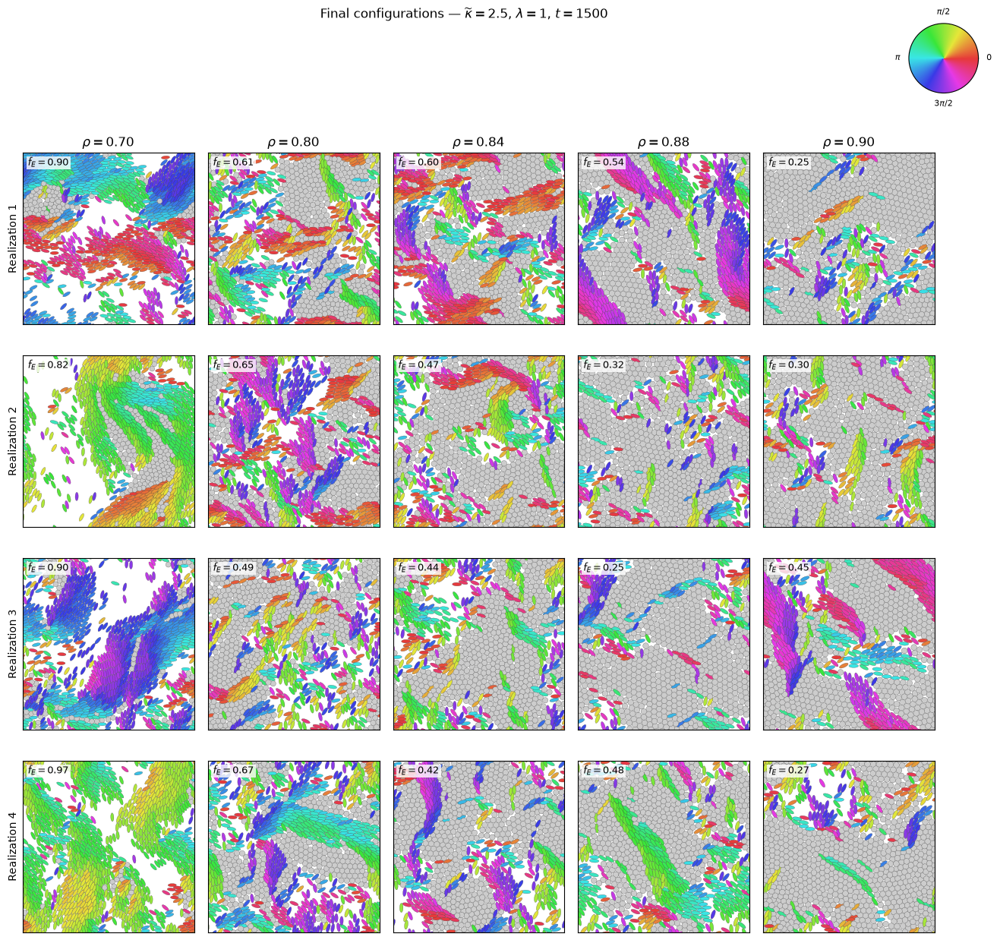

In [5]:
# One page per four seeds keeps snapshots readable as more realizations are added.
for page, offset in enumerate(range(0, len(SEEDS), 4), start=1):
    page_seeds = SEEDS[offset:offset+4]
    fig, axes = plt.subplots(len(page_seeds), len(DENSITIES),
                             figsize=(3.1*len(DENSITIES), 3.1*len(page_seeds)+1.7), squeeze=False)
    for row, seed in enumerate(page_seeds):
        for col, rho in enumerate(DENSITIES):
            key = (LAMBDA_CORE, KAPPA, rho, seed, FINAL_STEP)
            ax = axes[row, col]
            if key in snapshot_paths:
                draw_snapshot(ax, read_snapshot(snapshot_paths[key]))
            else:
                ax.text(.5, .5, "No run", ha="center", va="center", transform=ax.transAxes)
                ax.set(xticks=[], yticks=[])
            if row == 0:
                ax.set_title(rf"$\rho={rho:.2f}$")
            if col == 0:
                ax.set_ylabel(f"Realization {SEEDS.index(seed)+1}")
    fig.suptitle(rf"Final configurations — $\widetilde\kappa={KAPPA}$, $\lambda={LAMBDA_CORE:g}$, $t={FINAL_TIME:g}$", y=.98)
    fig.subplots_adjust(top=.85, hspace=.10, wspace=.08)
    add_orientation_wheel(fig)
    finish_figure(fig, f"01_final_configurations_page_{page}")

## 3. Temporal diagnostics

Each color identifies one realization. Read $f_E$, unweighted $P_E,Q_E$, and their weighted counterparts together. Unweighted order is undefined when no elongates remain and is masked. High order in a tiny population is not evidence of collective organization.

Motion is shown as the mean one-step displacement divided by $\Delta t$, not as a noise-independent instantaneous velocity. The overlap observable is the maximum over an output interval, not a pair average. The contraction threshold does not bound overlaps produced by subsequent motion.

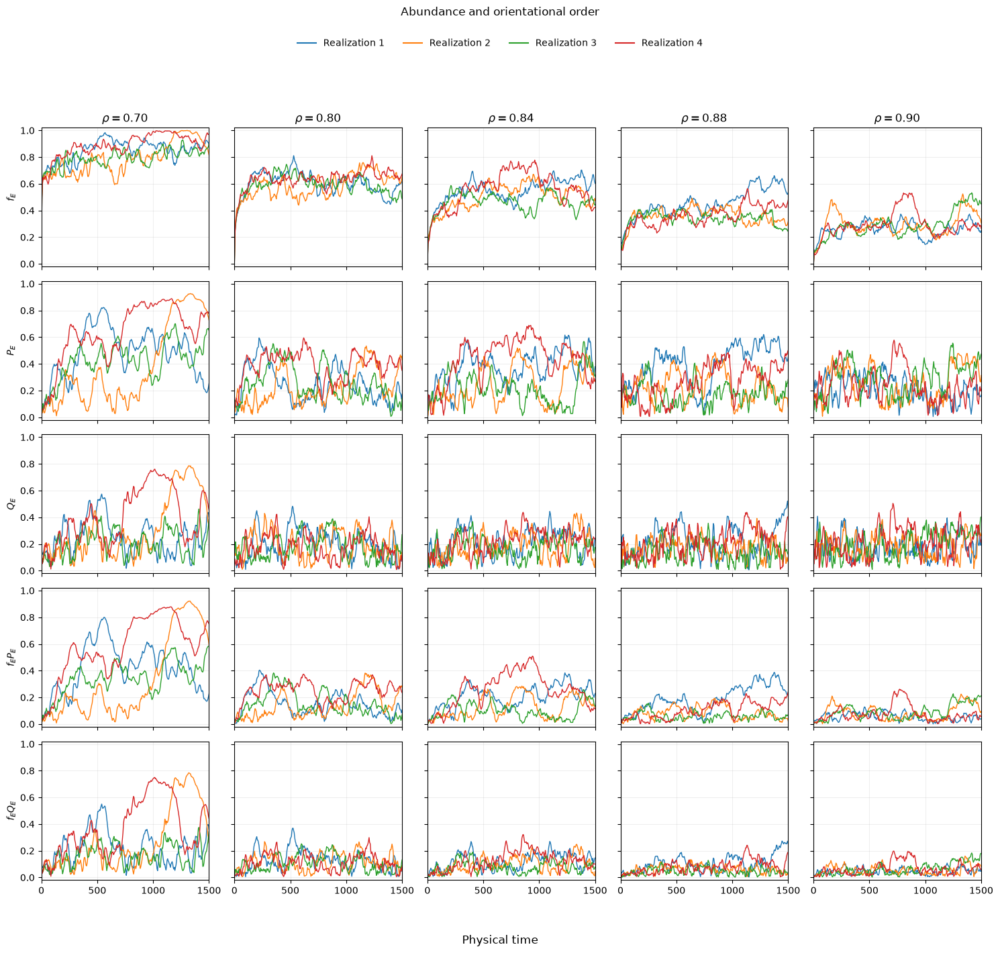

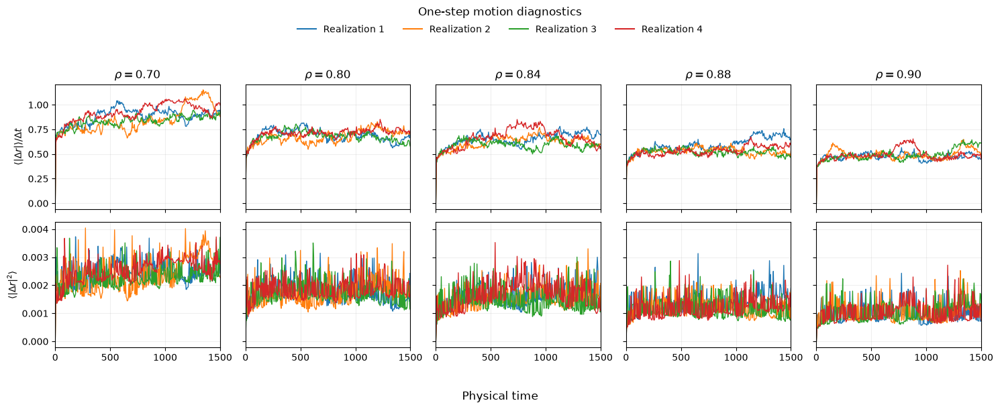

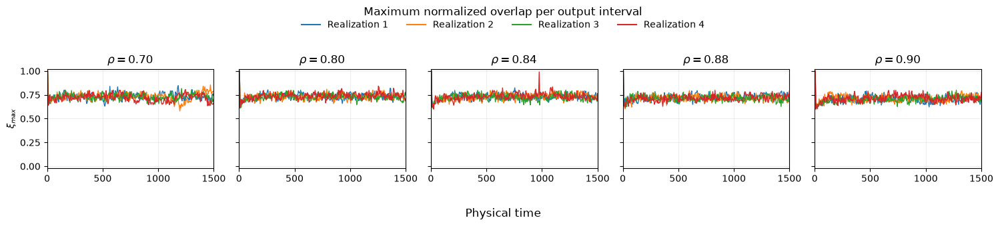

In [6]:
def time_panels(frame, specs, stem, title, bounded=False):
    fig, axes = plt.subplots(len(specs), len(DENSITIES), figsize=(max(14, 3*len(DENSITIES)), 2.7*len(specs)+.5), squeeze=False, sharex=True, sharey="row")
    for row, (column, label) in enumerate(specs):
        for col, rho in enumerate(DENSITIES):
            ax = axes[row, col]
            for seed in SEEDS:
                g = frame.loc[np.isclose(frame.rho, rho) & frame.seed.eq(seed)].sort_values("time")
                ax.plot(g.time, g[column], color=SEED_COLORS[seed], lw=1)
            if row == 0:
                ax.set_title(rf"$\rho={rho:.2f}$")
            if col == 0:
                ax.set_ylabel(label)
            if bounded:
                ax.set_ylim(-.02, 1.02)
            ax.set_xlim(0, FINAL_TIME)
            ax.grid(alpha=.2)
    fig.suptitle(title, y=1.01)
    fig.legend(handles=[Line2D([0], [0], color=SEED_COLORS[s], label=f"Realization {i+1}")
                        for i,s in enumerate(SEEDS)], loc="upper center", bbox_to_anchor=(.5,.985), ncol=4, frameon=False)
    fig.supxlabel("Physical time")
    fig.tight_layout(rect=(0,.03,1,.93))
    finish_figure(fig, stem)

order = order_parameters.copy()
order.loc[order.fraction_elongated.eq(0), ["polar", "nematic"]] = np.nan
time_panels(order, [("fraction_elongated", r"$f_E$"), ("polar", r"$P_E$"), ("nematic", r"$Q_E$"),
                    ("polar_2", r"$f_EP_E$"), ("nematic_2", r"$f_EQ_E$")],
            "02_order_timeseries", "Abundance and orientational order", bounded=True)
motion["mean_step_rate"] = motion.mean_step_displacement / DELTA_T
time_panels(motion, [("mean_step_rate", r"$\langle|\Delta r|\rangle/\Delta t$"),
                     ("mean_squared_step_displacement", r"$\langle|\Delta r|^2\rangle$")],
            "03_motion_timeseries", "One-step motion diagnostics")
time_panels(overlap, [("max_normalized_overlap", r"$\xi_{max}$")],
            "04_overlap_timeseries", "Maximum normalized overlap per output interval", bounded=True)

## 4. Density dependence across time windows

Compute one mean per realization in each interval `start < t <= end`. Points remain paired by seed across densities. These windows diagnose drift; temporal samples are correlated and are not treated as independent realizations. Counts are exported so missing or undefined observations remain visible.

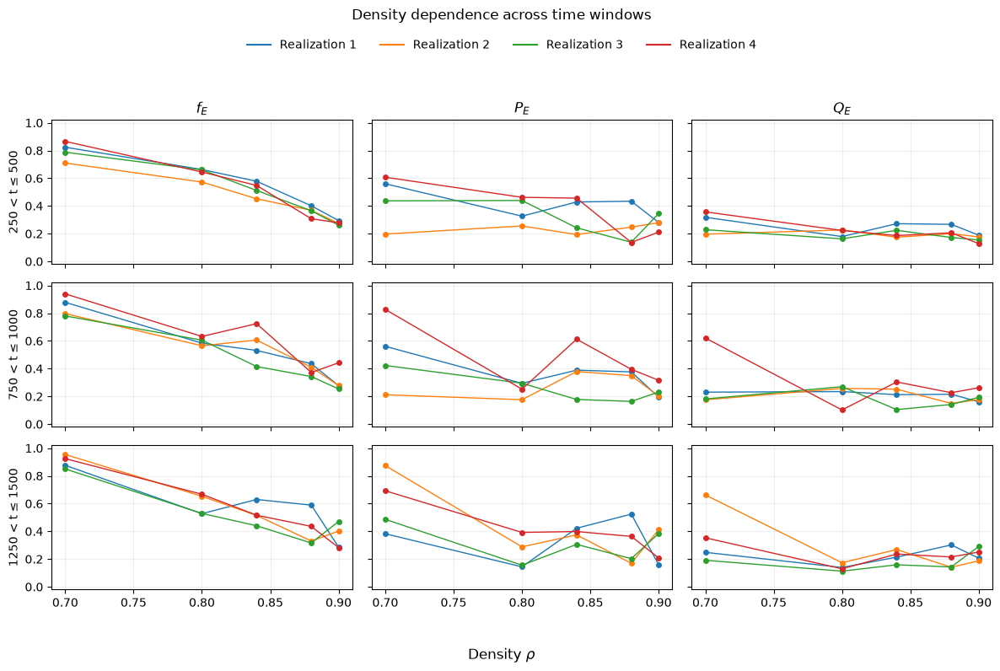

In [7]:
def window_means(frame, columns, extra_keys=()):
    keys = RUN_KEYS + list(extra_keys)
    records = []
    for start, end in TIME_WINDOWS:
        part = frame.loc[(frame.time > start) & (frame.time <= end)]
        means = part.groupby(keys, as_index=False)[columns].mean()
        counts = part.groupby(keys)[columns].count().add_prefix("n_valid_").reset_index()
        means = means.merge(counts, on=keys, validate="one_to_one")
        means["time_start"], means["time_end"] = start, end
        records.append(means)
    return pd.concat(records, ignore_index=True)

def density_panels(summary, specs, stem, title, selector=None):
    fig, axes = plt.subplots(len(TIME_WINDOWS), len(specs), figsize=(4*len(specs), 8), squeeze=False, sharex=True, sharey=True)
    for row, (start, end) in enumerate(TIME_WINDOWS):
        subset = summary.loc[summary.time_start.eq(start) & summary.time_end.eq(end)]
        if selector is not None:
            subset = selector(subset)
        for col, (column, label) in enumerate(specs):
            ax=axes[row,col]
            for seed in SEEDS:
                g=subset.loc[subset.seed.eq(seed)].sort_values("rho")
                ax.plot(g.rho,g[column],"o-",color=SEED_COLORS[seed],ms=4,lw=1)
            if row==0: ax.set_title(label)
            if col==0: ax.set_ylabel(f"{start} < t ≤ {end}")
            ax.set_ylim(-.02,1.02); ax.grid(alpha=.2)
    fig.suptitle(title)
    fig.legend(handles=[Line2D([0],[0],color=SEED_COLORS[s],label=f"Realization {i+1}") for i,s in enumerate(SEEDS)], loc="upper center",bbox_to_anchor=(.5,.95),ncol=4,frameon=False)
    fig.supxlabel(r"Density $\rho$")
    fig.tight_layout(rect=(0,.03,1,.90))
    finish_figure(fig,stem)

order["n_elongated"] = order.fraction_elongated * order.actual_N
order_windows = window_means(order, ["fraction_elongated", "polar", "nematic", "polar_2", "nematic_2", "n_elongated"])
density_panels(order_windows, [("fraction_elongated",r"$f_E$"),("polar",r"$P_E$"),("nematic",r"$Q_E$")],
               "05_order_windows", "Density dependence across time windows")

## 5. Connectivity of elongated and round populations

Analyze two separate graphs: elongated vertices only, or round vertices only. The other population cannot bridge components; isolated cells count as components of size one.
Cells are round when `np.isclose(major / minor, 1)`; every other shape is classified as elongated, as in the previous analysis.

For semi-axis matrices $B_i=\mathcal R(\phi_i)\operatorname{diag}(a_i^2,b_i^2)\mathcal R(\phi_i)^T$,
$$\xi_{ij}=\exp[-\tfrac12\mathbf r_{ij}^T(B_i+B_j)^{-1}\mathbf r_{ij}].$$
Use minimum-image displacements in the periodic box. For fixed shape and direction, $\xi(r)=e^{-qr^2}$, so a range factor $b$ gives $\xi_{\mathrm{cluster}}=(\xi_{\mathrm{cut}})^{b^2}=e^{-b^2}$.

| Range extension | Overlap threshold |
|---|---|
| 0% | 0.367879 |
| 10% | 0.298197 |
| 20% | 0.236928 |

This extends the **interaction-threshold range**, not necessarily geometric contact distance.
For each threshold, the elongated population has two graphs: overlap alone and overlap plus $\cos(\phi_i-\phi_j)\ge\cos45^\circ$.
Round cells have only the overlap graph: their shape orientation is not used to define polar clusters.
For identical round cells, $\xi=e^{-r^2/(4R^2)}$, so these cutoffs correspond to $r<2Rb$.

For either population $X\in\{E,R\}$,
$$f_X=N_X/N,\qquad C_X=S_{\max,X}/N_X,\qquad G_X=S_{\max,X}/N=f_XC_X.$$
If $N_X=0$, $C_X$ is undefined and $G_X=0$.
Although $f_R=1-f_E$, the largest-component fractions are not complements.
Read abundance and connectivity together: changing the population size can affect connectivity even when using $C_X$.

One neighbor search per population covers all its thresholds, and pair overlaps are reused.
The cache is updated per realization: adding completed runs computes only new or modified realizations.
File size/modification-time signatures detect input changes; set `RECOMPUTE_CONNECTIVITY=True` to force a rebuild.

In [8]:
def normalized_pair_overlap(major, minor, phi, pairs, displacements):
    """Evaluate normalized Gaussian overlap for the supplied pairs."""
    cosine = np.cos(phi)
    sine = np.sin(phi)

    # Shape matrix B = rotation @ diag(major², minor²) @ rotation.T
    bxx = major**2 * cosine**2 + minor**2 * sine**2
    byy = major**2 * sine**2 + minor**2 * cosine**2
    bxy = (major**2 - minor**2) * cosine * sine

    i, j = pairs.T

    # Normalized overlap: exp[-r.T @ inv(B_i + B_j) @ r / 2]
    sxx = bxx[i] + bxx[j]
    syy = byy[i] + byy[j]
    sxy = bxy[i] + bxy[j]
    determinant = sxx * syy - sxy**2

    dx, dy = displacements.T
    exponent = 0.5 * (
        syy * dx**2
        - 2 * sxy * dx * dy
        + sxx * dy**2
    ) / determinant

    return np.exp(-exponent)



def summarize_components(n_population, pairs, total_cells):
    """Undirected connected components, including isolates and empty populations."""
    if n_population == 0:
        return dict(n_population=0, fraction_population=0.0, n_edges=0,
                    n_components=0, largest_size=0, C=np.nan, G=0.0), np.empty(0, dtype=int)
    graph = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])),
                       shape=(n_population, n_population)).tocsr()
    n_components, labels = connected_components(graph, directed=False)
    largest = int(np.bincount(labels, minlength=n_components).max())
    return dict(n_population=n_population, fraction_population=n_population/total_cells,
                n_edges=len(pairs), n_components=n_components, largest_size=largest,
                C=largest/n_population, G=largest/total_cells), labels


def analyze_connectivity(snapshot, with_labels=False):
    """Six elongated graphs and three round graphs from one saved configuration."""
    is_round = np.isclose(snapshot["major"] / snapshot["minor"], 1.0)
    total_cells = len(is_round)
    box = snapshot["box"]
    records, labels_out = [], {}
    for population, mask in [("elongated", ~is_round), ("round", is_round)]:
        positions = snapshot["positions"][mask]
        major, minor, phi = [snapshot[n][mask] for n in ("major", "minor", "phi")]
        pairs = np.empty((0, 2), dtype=int)
        xi = np.empty(0)
        aligned = np.empty(0, dtype=bool)
        if len(phi) > 1:
            search_radius = 2*major.max()*max(RANGE_FACTORS)*np.sqrt(-np.log(XI_CUT))
            pairs = cKDTree(positions, boxsize=box).query_pairs(search_radius, output_type="ndarray")
            dr = positions[pairs[:, 1]] - positions[pairs[:, 0]]
            dr -= box*np.rint(dr/box)
            xi = normalized_pair_overlap(major, minor, phi, pairs, dr)
            if population == "elongated":
                aligned = np.cos(phi[pairs[:, 0]]-phi[pairs[:, 1]]) >= np.cos(np.deg2rad(POLAR_ANGLE_DEG))
        filters = (False, True) if population == "elongated" else (False,)
        for factor in RANGE_FACTORS:
            threshold = XI_CUT**(factor**2)
            for polar_filter in filters:
                selected = xi > threshold
                if polar_filter:
                    selected &= aligned
                summary, labels = summarize_components(len(phi), pairs[selected], total_cells)
                # Keep population-specific columns for easy comparisons with earlier exports.
                symbol = POPULATION_SYMBOLS[population]
                aliases = {f"C_{symbol}": summary["C"], f"G_{symbol}": summary["G"],
                           f"n_{population}": summary["n_population"],
                           f"fraction_{population}": summary["fraction_population"]}
                records.append(dict(population=population, range_factor=factor, xi_threshold=threshold,
                                    polar_filter=polar_filter, polar_angle_deg=POLAR_ANGLE_DEG,
                                    **summary, **aliases))
                if with_labels:
                    full = np.full(total_cells, -1, dtype=int)
                    full[mask] = labels
                    labels_out[(population, factor, polar_filter)] = full
    return records, labels_out

In [9]:
assert CONNECTIVITY_STEP >= OUTPUT_STEP and CONNECTIVITY_STEP % OUTPUT_STEP == 0
assert FINAL_STEP % CONNECTIVITY_STEP == 0
assert 0 < XI_CUT < 1 and min(RANGE_FACTORS) >= 1
selected_paths = {key: p for key, p in snapshot_paths.items() if key[-1] % CONNECTIVITY_STEP == 0}
settings = dict(algorithm_version=2, delta_t=DELTA_T, final_step=FINAL_STEP,
                xi_cut=float(XI_CUT), range_factors=RANGE_FACTORS, polar_angle_deg=POLAR_ANGLE_DEG,
                connectivity_step=CONNECTIVITY_STEP, populations=["elongated", "round"],
                round_rtol=1e-5, round_atol=1e-8)
cache_path = TABLE_DIR / "connectivity_timeseries.parquet"
cache_meta = TABLE_DIR / "connectivity_cache.json"
previous_meta = json.loads(cache_meta.read_text()) if cache_meta.exists() else {}
cache_usable = (not RECOMPUTE_CONNECTIVITY and cache_path.exists()
                and previous_meta.get("settings") == settings)
cached = pd.read_parquet(cache_path) if cache_usable else pd.DataFrame()
cached_runs = ({tuple(key): g for key, g in cached.groupby(RUN_KEYS)} if cache_usable else {})
run_paths = {}
for key, path in sorted(selected_paths.items()):
    run_paths.setdefault(key[:-1], []).append((key, path))
phenotype = order_parameters.set_index(RUN_KEYS+["step"])["fraction_elongated"]
chunks, signatures = [], {}
reused_runs = computed_runs = 0
for run_index, (run_key, paths) in enumerate(sorted(run_paths.items()), start=1):
    run_id = json.dumps(list(run_key))
    manifest = [(list(key), p.name, p.stat().st_size, p.stat().st_mtime_ns) for key, p in paths]
    signature = hashlib.sha256(json.dumps(manifest, sort_keys=True).encode()).hexdigest()
    signatures[run_id] = signature
    expected_rows = len(paths)*len(RANGE_FACTORS)*3
    reuse = (run_key in cached_runs and previous_meta.get("run_signatures", {}).get(run_id) == signature
             and len(cached_runs[run_key]) == expected_rows)
    if reuse:
        chunks.append(cached_runs[run_key])
        reused_runs += 1
    else:
        rows = []
        for key, path in paths:
            snapshot = read_snapshot(path)
            observed = np.mean(~np.isclose(snapshot["major"]/snapshot["minor"], 1.0))
            assert len(snapshot["phi"]) == EXPECTED_N
            assert np.isclose(observed, phenotype.loc[key], atol=2e-6), f"Phenotype mismatch: {key}"
            records, _ = analyze_connectivity(snapshot)
            metadata = dict(zip(RUN_KEYS+["step"], key))
            metadata["time"] = key[-1]*DELTA_T
            rows.extend({**metadata, **r} for r in records)
        chunks.append(pd.DataFrame(rows))
        computed_runs += 1
    print(f"Connectivity: run {run_index}/{len(run_paths)} ({'cache' if reuse else 'computed'})", flush=True)
connectivity = pd.concat(chunks, ignore_index=True).sort_values(
    RUN_KEYS+["step", "population", "range_factor", "polar_filter"]).reset_index(drop=True)
keys = RUN_KEYS+["step", "population", "range_factor", "polar_filter"]
assert not connectivity.duplicated(keys).any()
assert len(connectivity) == len(selected_paths)*len(RANGE_FACTORS)*3
assert np.allclose(connectivity.G, connectivity.fraction_population*connectivity.C.fillna(0))
assert connectivity.C.isna().equals(connectivity.n_population.eq(0))
assert connectivity.largest_size.le(connectivity.n_population).all()
assert not connectivity.loc[connectivity.population.eq("round"), "polar_filter"].any()
pivot = connectivity.loc[connectivity.population.eq("elongated")].pivot(
    index=RUN_KEYS+["step", "range_factor"], columns="polar_filter", values="largest_size")
assert (pivot[True] <= pivot[False]).all()
monotone = connectivity.pivot(index=RUN_KEYS+["step", "population", "polar_filter"],
                              columns="range_factor", values="largest_size")
assert (np.diff(monotone.sort_index(axis=1).to_numpy(), axis=1) >= 0).all()
fractions = connectivity.loc[~connectivity.polar_filter].pivot(
    index=RUN_KEYS+["step", "range_factor"], columns="population", values="fraction_population")
assert np.allclose(fractions.elongated+fractions["round"], 1)
connectivity.to_parquet(cache_path, index=False)
cache_meta.write_text(json.dumps(dict(settings=settings, run_signatures=signatures), indent=2))
print(f"Validated {len(connectivity)} summaries; {computed_runs} computed and {reused_runs} cached runs.")

Connectivity: run 1/20 (cache)
Connectivity: run 2/20 (cache)
Connectivity: run 3/20 (cache)
Connectivity: run 4/20 (cache)
Connectivity: run 5/20 (cache)
Connectivity: run 6/20 (cache)
Connectivity: run 7/20 (cache)
Connectivity: run 8/20 (cache)
Connectivity: run 9/20 (cache)
Connectivity: run 10/20 (cache)
Connectivity: run 11/20 (cache)
Connectivity: run 12/20 (cache)
Connectivity: run 13/20 (cache)
Connectivity: run 14/20 (cache)
Connectivity: run 15/20 (cache)
Connectivity: run 16/20 (cache)
Connectivity: run 17/20 (cache)
Connectivity: run 18/20 (cache)
Connectivity: run 19/20 (cache)
Connectivity: run 20/20 (cache)
Validated 54180 summaries; 0 computed and 20 cached runs.


## 6. Cluster trajectories: raw data and optional smoothing

Colors identify realizations. Bold curves use a centered moving mean over `CLUSTER_SMOOTHING_TIME` physical-time units (default 25); faint curves retain the raw series.
Use `None` or `0` to disable smoothing. Windows shorten at the ends of a series and at undefined values; missing-population intervals are never filled or bridged.

This view helps follow organization and fragmentation, but it suppresses brief events. **Window means and ensemble statistics below always use raw data.**
Largest-component size does not track the identity or lifetime of a particular cluster.

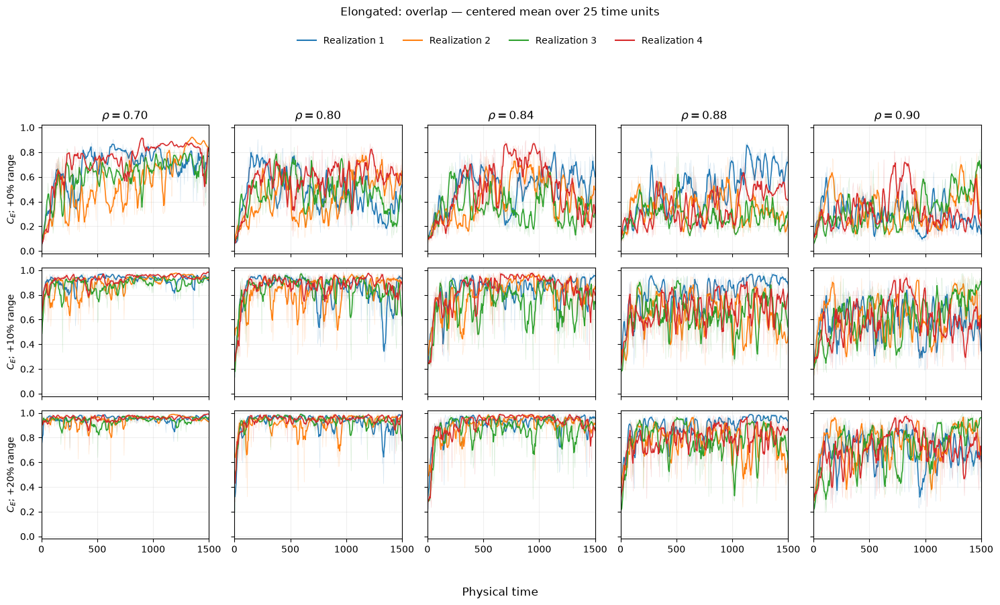

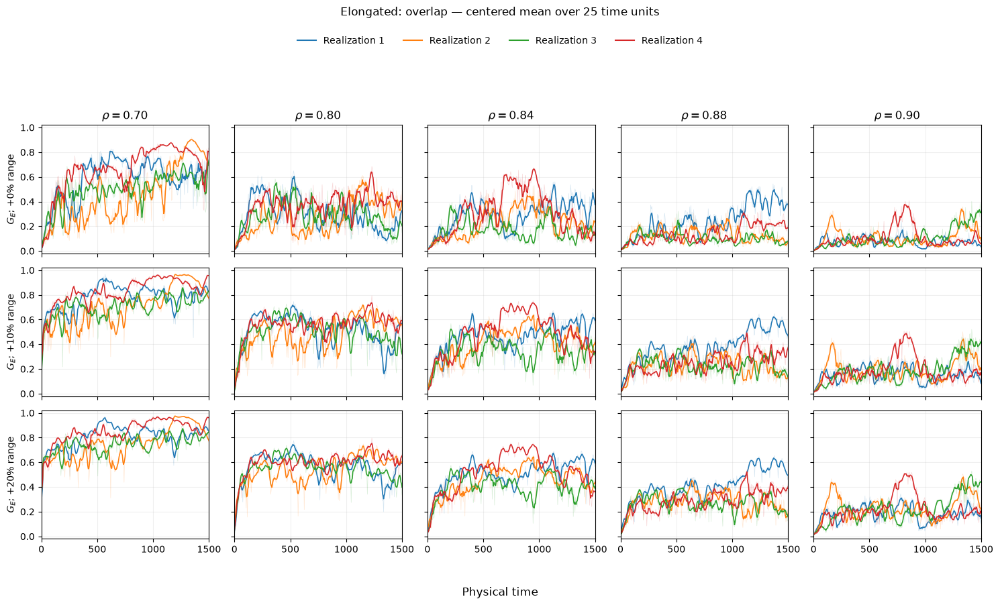

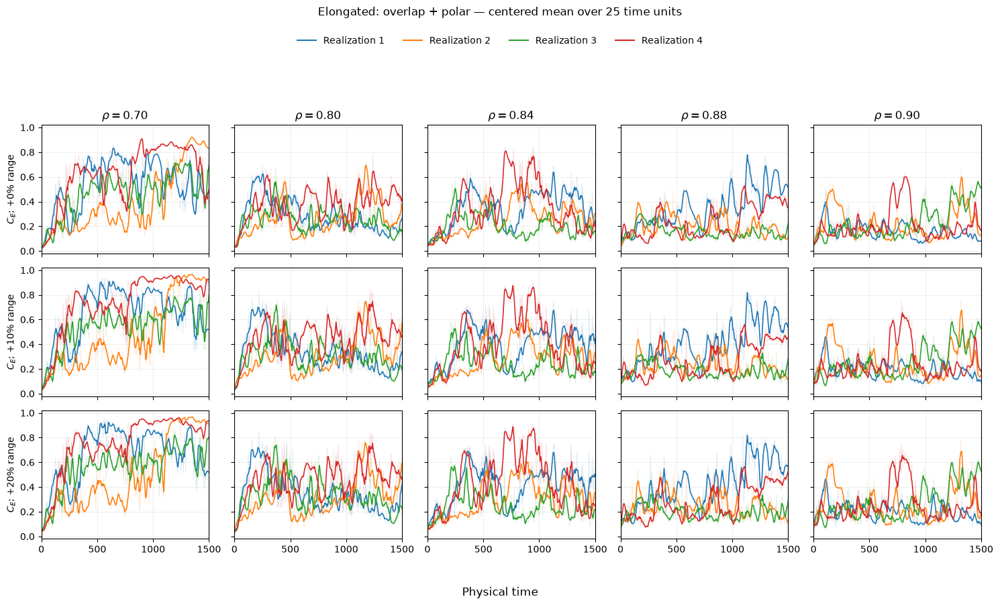

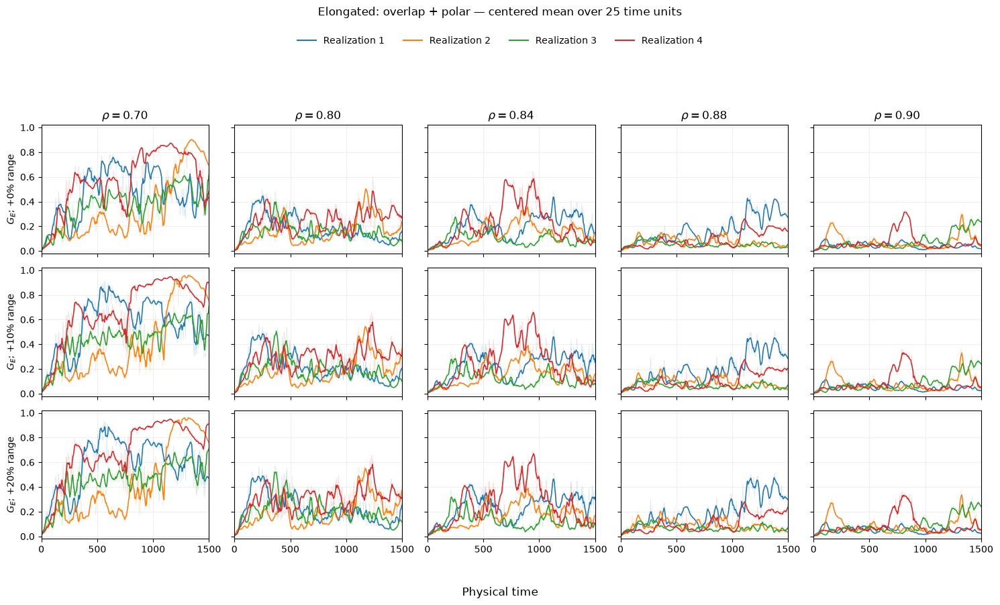

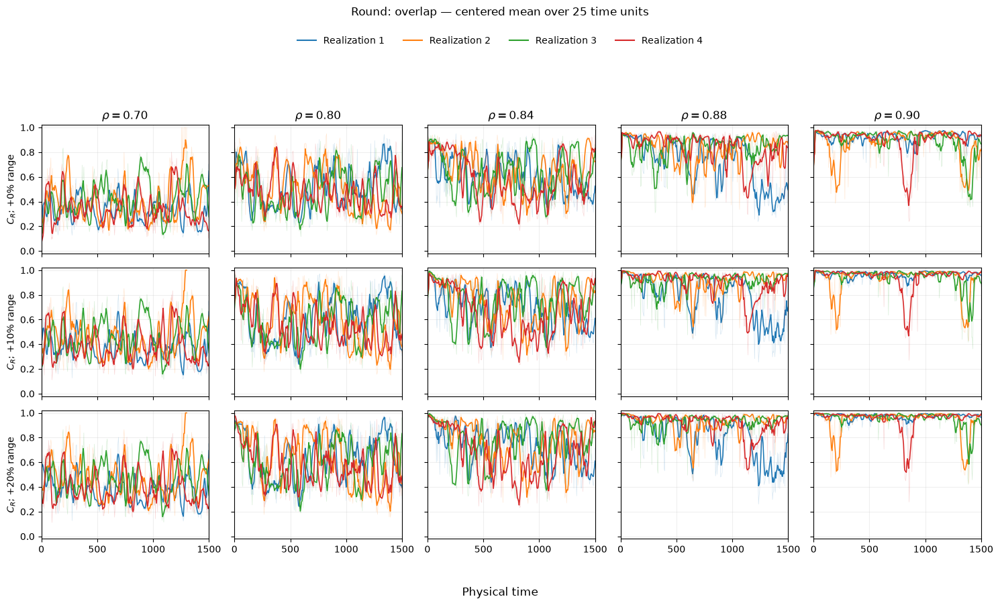

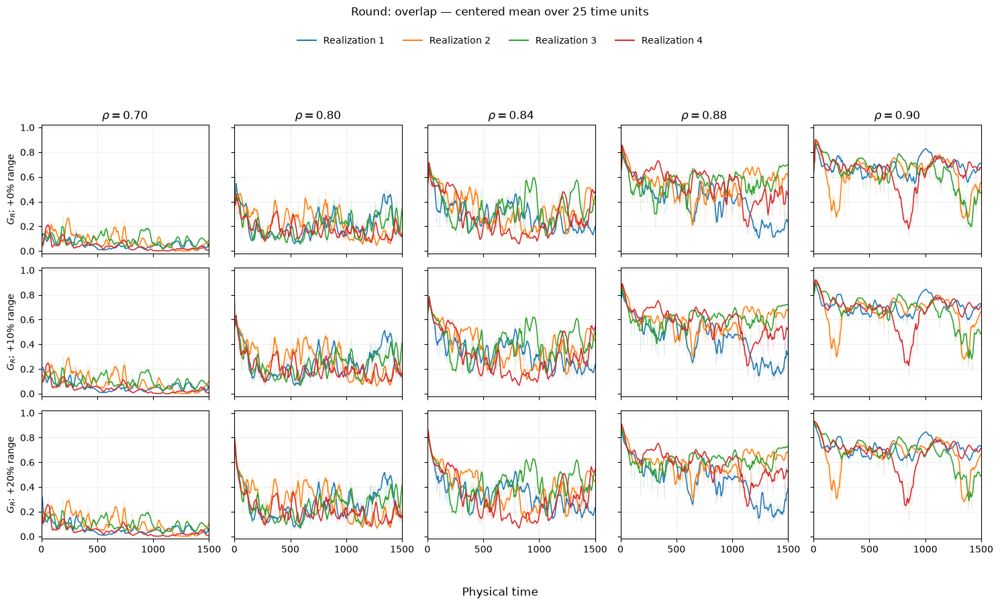

In [10]:
def smooth_cluster_curve(time, values, width=CLUSTER_SMOOTHING_TIME):
    """Centered physical-time moving mean, split at missing values and time gaps."""
    time, values = np.asarray(time, float), np.asarray(values, float)
    if width is None or width <= 0 or len(values) < 2:
        return values.copy()
    result = np.full(values.shape, np.nan)
    valid = np.flatnonzero(np.isfinite(values))
    if len(valid) == 0:
        return result
    cuts = np.flatnonzero((np.diff(valid) != 1)
                         | (np.diff(time[valid]) > CONNECTIVITY_STEP*DELTA_T*1.01)) + 1
    for indices in np.split(valid, cuts):
        series = pd.Series(values[indices], index=pd.to_timedelta(time[indices], unit="s"))
        result[indices] = series.rolling(pd.Timedelta(seconds=float(width)),
                                        center=True, min_periods=1).mean().to_numpy()
    return result

def graph_name(population, polar_filter):
    return POPULATION_NAMES[population] + (": overlap + polar" if polar_filter else ": overlap")

for population, polar_filter in GRAPH_CHOICES:
    symbol = POPULATION_SYMBOLS[population]
    for metric in ("C", "G"):
        fig, axes = plt.subplots(len(RANGE_FACTORS), len(DENSITIES),
                                  figsize=(max(14, 3*len(DENSITIES)), 9), squeeze=False,
                                  sharex=True, sharey=True)
        selected = connectivity.loc[connectivity.population.eq(population)
                                    & connectivity.polar_filter.eq(polar_filter)]
        for row, factor in enumerate(RANGE_FACTORS):
            for col, rho in enumerate(DENSITIES):
                ax = axes[row, col]
                part = selected.loc[np.isclose(selected.range_factor, factor) & np.isclose(selected.rho, rho)]
                for seed, group in part.groupby("seed"):
                    group = group.sort_values("time")
                    raw = group[metric].to_numpy()
                    if SHOW_RAW_CLUSTER_CURVES and CLUSTER_SMOOTHING_TIME:
                        ax.plot(group.time, raw, color=SEED_COLORS[seed], lw=.5, alpha=.18)
                    ax.plot(group.time, smooth_cluster_curve(group.time, raw), color=SEED_COLORS[seed], lw=1.15)
                if row == 0:
                    ax.set_title(rf"$\rho={rho:.2f}$")
                if col == 0:
                    ax.set_ylabel(rf"${metric}_{symbol}$" + f"; +{100*(factor-1):.0f}% range")
                ax.set(xlim=(0, FINAL_TIME), ylim=(-.02, 1.02))
                ax.grid(alpha=.2)
        description = (f"centered mean over {CLUSTER_SMOOTHING_TIME:g} time units"
                       if CLUSTER_SMOOTHING_TIME else "raw data")
        fig.suptitle(f"{graph_name(population, polar_filter)} — {description}", y=.99)
        fig.legend(handles=seed_handles(), loc="upper center", bbox_to_anchor=(.5, .955), ncol=4, frameon=False)
        fig.supxlabel("Physical time")
        fig.tight_layout(rect=(0, .03, 1, .87))
        suffix = "overlap_polar" if polar_filter else "overlap"
        finish_figure(fig, f"06_{population}_{suffix}_{metric}_{symbol}_timeseries")

## 7. Density dependence averaged over realizations

First compute one temporal mean $\overline X_s$ per seed and window, using the original samples in `start < t <= end`.
Then give each seed equal weight:
$$\langle\overline X\rangle_{\mathrm{runs}}=\frac1n\sum_{s=1}^n\overline X_s.$$
Markers and error bars show this mean **± one sample standard deviation between realizations**, not a confidence interval. Faint points show individual seed means.
The number of contributing seeds and the standard error (`std / sqrt(n)`) are exported; correlated time samples are never counted as independent runs.

For $C_X$, empty-population samples are excluded from the per-run mean and a run with no defined samples is excluded from the ensemble mean. For $G_X$, an empty population contributes zero. Valid sample and seed counts remain in the tables.
The identity $G_X=f_XC_X$ holds at each frame, but generally $\langle G_X\rangle\ne\langle f_X\rangle\langle C_X\rangle$.

The same three thresholds are shown for elongated spatial, elongated polar, and round spatial connectivity. Round connectivity tests a complementary population; an increase can also reflect the rise of $f_R$, not a separate phase transition by itself.

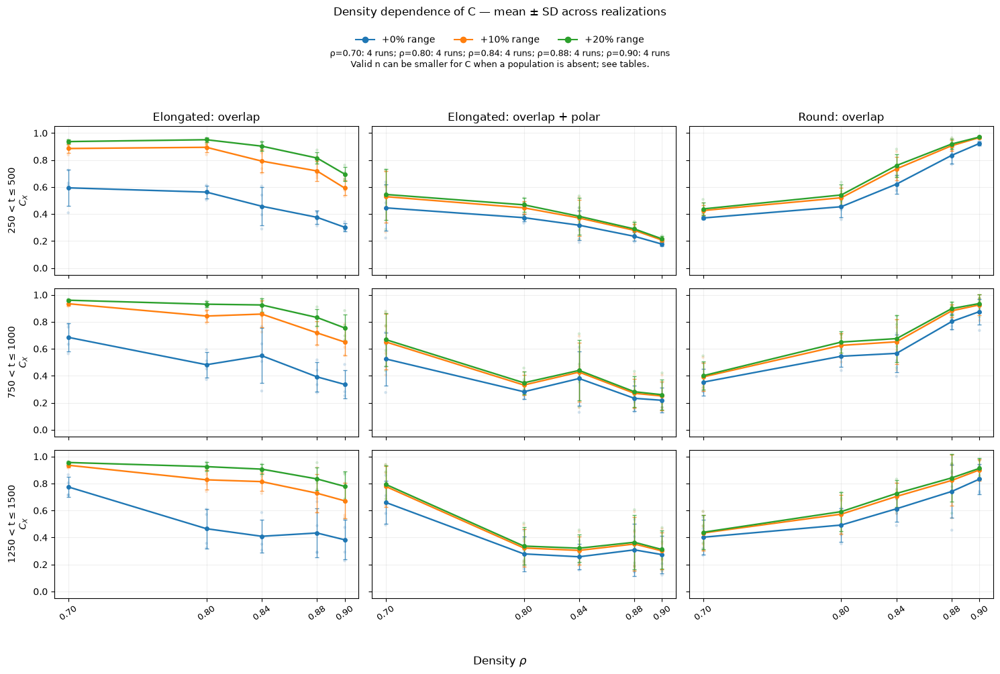

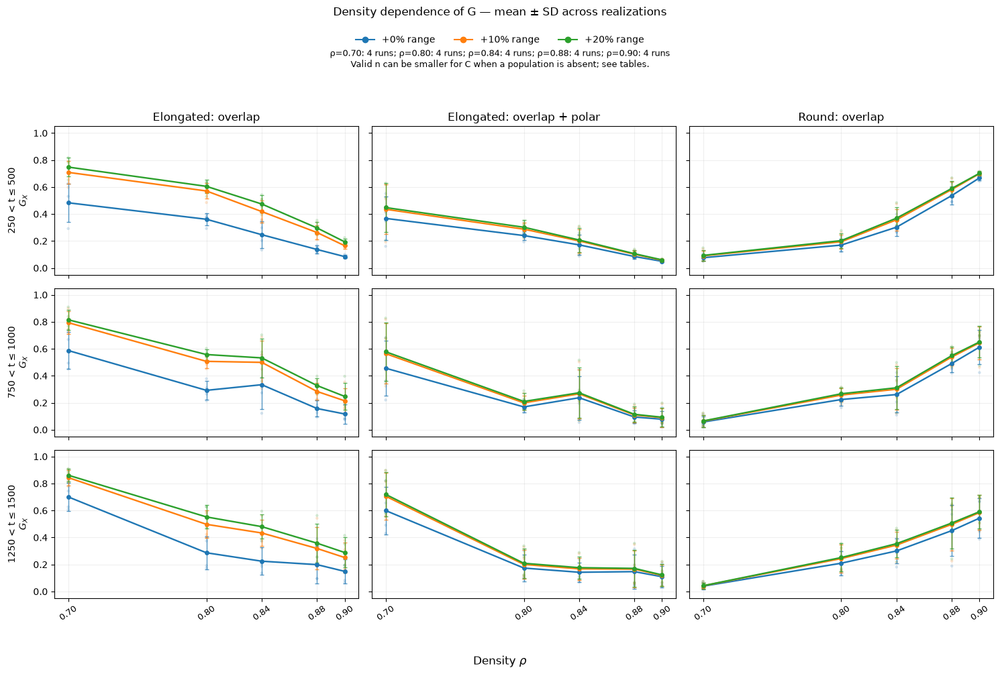

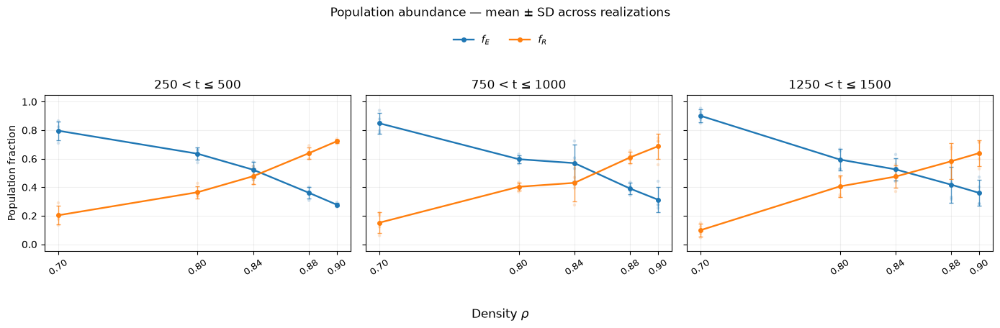

,rho,population,polar_filter,metric,mean,std,sem,n,n_total
20,0.70,elongated,False,C,0.9355,0.0158,0.0079,4,4
21,0.70,elongated,True,C,0.7787,0.1526,0.0763,4,4
25,0.70,round,False,C,0.4332,0.1311,0.0656,4,4
47,0.80,elongated,False,C,0.8275,0.0728,0.0364,4,4
48,0.80,elongated,True,C,0.3222,0.1378,0.0689,4,4
52,0.80,round,False,C,0.5728,0.1442,0.0721,4,4
74,0.84,elongated,False,C,0.8140,0.0671,0.0335,4,4
75,0.84,elongated,True,C,0.3042,0.1047,0.0524,4,4
79,0.84,round,False,C,0.7044,0.0980,0.0490,4,4
101,0.88,elongated,False,C,0.7281,0.1398,0.0699,4,4


In [11]:
connectivity_windows = window_means(
    connectivity, ["C", "G", "fraction_population", "n_population", "largest_size", "n_components"],
    extra_keys=["population", "range_factor", "polar_filter", "xi_threshold", "polar_angle_deg"])

def ensemble_summary(summary, metrics, extra_keys=()):
    """Equal weight per run, after temporal averaging; keep valid and total seed counts."""
    keys = ["lambda_core", "kappa", "rho", "time_start", "time_end"] + list(extra_keys)
    assert not summary.duplicated(keys+["seed"]).any()
    pieces = []
    for metric in metrics:
        group = summary.groupby(keys)[metric]
        result = group.agg(mean="mean", std="std", n="count", n_total="size").reset_index()
        result["sem"] = result["std"] / np.sqrt(result["n"].replace(0, np.nan))
        result["metric"] = metric
        pieces.append(result)
    return pd.concat(pieces, ignore_index=True)

ensemble_keys = ["population", "range_factor", "polar_filter", "xi_threshold", "polar_angle_deg"]
connectivity_ensemble = ensemble_summary(
    connectivity_windows, ["C", "G", "fraction_population", "n_population", "largest_size", "n_components"],
    extra_keys=ensemble_keys)
order_ensemble = ensemble_summary(order_windows, ["fraction_elongated", "polar", "nematic", "polar_2", "nematic_2"])

def draw_density_average(ax, individual, ensemble, column, color, label):
    ax.scatter(individual.rho, individual[column], s=10, color=color, alpha=.20, edgecolors="none", zorder=1)
    group = ensemble.sort_values("rho")
    ax.plot(group.rho, group["mean"], "o-", color=color, lw=1.7, ms=4, label=label, zorder=3)
    # A single contributing realization has undefined SD: show its point without an error bar.
    defined = group["std"].notna()
    ax.errorbar(group.loc[defined, "rho"], group.loc[defined, "mean"],
                yerr=group.loc[defined, "std"], fmt="none", ecolor=color,
                elinewidth=1, capsize=2.5, alpha=.75, zorder=2)

for metric in ("C", "G"):
    fig, axes = plt.subplots(len(TIME_WINDOWS), len(GRAPH_CHOICES), figsize=(15, 10),
                              squeeze=False, sharex=True, sharey=True)
    for row, (start, end) in enumerate(TIME_WINDOWS):
        for col, (population, polar_filter) in enumerate(GRAPH_CHOICES):
            ax = axes[row, col]
            for factor in RANGE_FACTORS:
                common = (connectivity_windows.time_start.eq(start) & connectivity_windows.time_end.eq(end)
                          & connectivity_windows.population.eq(population)
                          & connectivity_windows.polar_filter.eq(polar_filter)
                          & np.isclose(connectivity_windows.range_factor, factor))
                averaged = connectivity_ensemble.loc[
                    connectivity_ensemble.time_start.eq(start) & connectivity_ensemble.time_end.eq(end)
                    & connectivity_ensemble.population.eq(population)
                    & connectivity_ensemble.polar_filter.eq(polar_filter)
                    & np.isclose(connectivity_ensemble.range_factor, factor)
                    & connectivity_ensemble.metric.eq(metric)]
                draw_density_average(ax, connectivity_windows.loc[common], averaged, metric,
                                     RANGE_COLORS[factor], f"+{100*(factor-1):.0f}% range")
            if row == 0:
                ax.set_title(graph_name(population, polar_filter))
            if col == 0:
                ax.set_ylabel(f"{start} < t ≤ {end}\n" + rf"${metric}_X$")
            ax.set(ylim=(-.05, 1.05), xticks=DENSITIES)
            ax.tick_params(axis="x", labelsize=9, rotation=35)
            ax.grid(alpha=.2)
    handles = [Line2D([0], [0], marker="o", color=RANGE_COLORS[b], label=f"+{100*(b-1):.0f}% range") for b in RANGE_FACTORS]
    fig.suptitle(f"Density dependence of {metric} — mean ± SD across realizations", y=.995)
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(.5, .965), ncol=3, frameon=False)
    counts_label = "; ".join(f"ρ={r.rho:.2f}: {int(r.n_realizations)} runs" for r in run_counts.itertuples())
    fig.text(.5, .905, counts_label + "\nValid n can be smaller for C when a population is absent; see tables.",
             ha="center", fontsize=9)
    fig.supxlabel(r"Density $\rho$")
    fig.tight_layout(rect=(0, .03, 1, .885))
    finish_figure(fig, f"07_{metric}_ensemble_density")

# Population abundance provides context for the connectivity means.
fig, axes = plt.subplots(1, len(TIME_WINDOWS), figsize=(14, 4.5), squeeze=False, sharey=True)
for ax, (start, end) in zip(axes[0], TIME_WINDOWS):
    individuals = order_windows.loc[order_windows.time_start.eq(start) & order_windows.time_end.eq(end)]
    means = order_ensemble.loc[order_ensemble.time_start.eq(start) & order_ensemble.time_end.eq(end)
                               & order_ensemble.metric.eq("fraction_elongated")]
    draw_density_average(ax, individuals, means, "fraction_elongated", "tab:blue", r"$f_E$")
    round_individuals, round_means = individuals.copy(), means.copy()
    round_individuals["fraction_round"] = 1-round_individuals.fraction_elongated
    round_means["mean"] = 1-round_means["mean"]  # SD is unchanged by this affine transformation.
    draw_density_average(ax, round_individuals, round_means, "fraction_round", "tab:orange", r"$f_R$")
    ax.set(title=f"{start} < t ≤ {end}", ylim=(-.05, 1.05), xticks=DENSITIES)
    ax.tick_params(axis="x", labelsize=9, rotation=35)
    ax.grid(alpha=.2)
axes[0, 0].set_ylabel("Population fraction")
fig.suptitle("Population abundance — mean ± SD across realizations")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="upper center", bbox_to_anchor=(.5, .92), ncol=2, frameon=False)
fig.supxlabel(r"Density $\rho$")
fig.tight_layout(rect=(0, .04, 1, .86))
finish_figure(fig, "07_population_fractions_ensemble_density")

late_start, late_end = TIME_WINDOWS[-1]
display(connectivity_ensemble.loc[
    connectivity_ensemble.time_start.eq(late_start) & connectivity_ensemble.time_end.eq(late_end)
    & connectivity_ensemble.metric.isin(["C", "G"]) & np.isclose(connectivity_ensemble.range_factor, 1.1),
    ["rho", "population", "polar_filter", "metric", "mean", "std", "sem", "n", "n_total"]].round(4))

## 8. Component maps

For each selected seed, compare thresholds with and without polar alignment in the elongated population.
Colors rank components by size **within each panel** and do not track identity between frames or criteria. All minor components share a pale color; they are not one connected group. The excluded population is gray.

`PLOT_ROUND_COMPONENT_MAPS=True` also creates spatial component maps of the round population. Use `MAP_SEEDS` or `PLOT_COMPONENT_MAPS=False` to reduce rendering time. `MAP_STEP` selects the saved frame.

In [12]:
COMPONENT_COLORS = ["#3979B5", "#E58A36", "#4F9A69", "#9567A5", "#997253"]
SMALL_COMPONENT_COLOR = "#CBDCE8"


def component_facecolors(labels):
    colors = np.tile(plt.matplotlib.colors.to_rgba(ROUND_COLOR), (len(labels), 1))
    included = labels >= 0
    colors[included] = plt.matplotlib.colors.to_rgba(SMALL_COMPONENT_COLOR)
    if included.any():
        sizes = np.bincount(labels[included])
        ranked = np.argsort(-sizes, kind="stable")
        for component, color in zip(ranked, COMPONENT_COLORS):
            colors[labels == component] = plt.matplotlib.colors.to_rgba(color)
    return colors

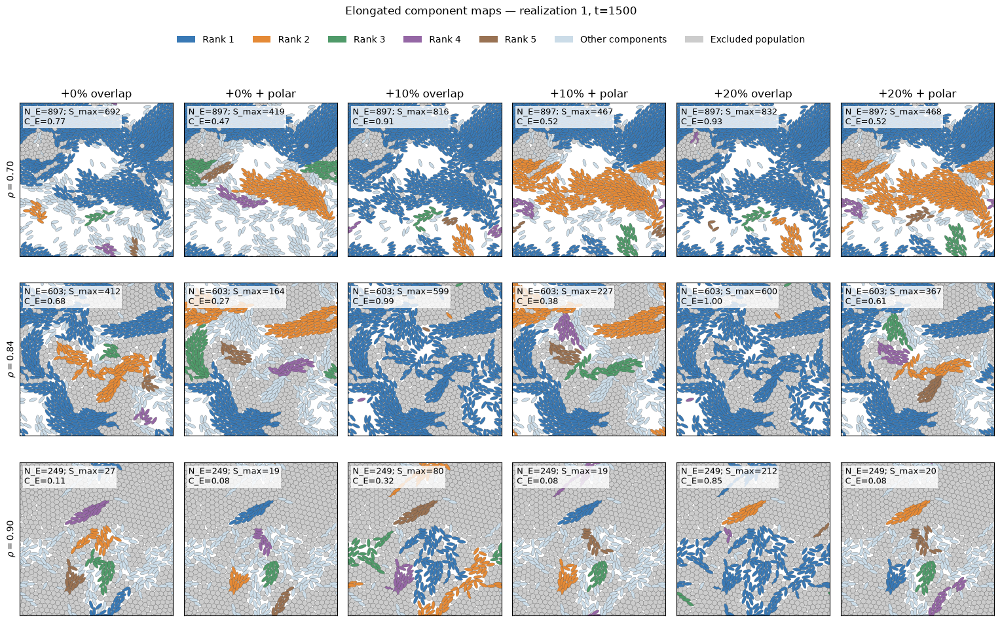

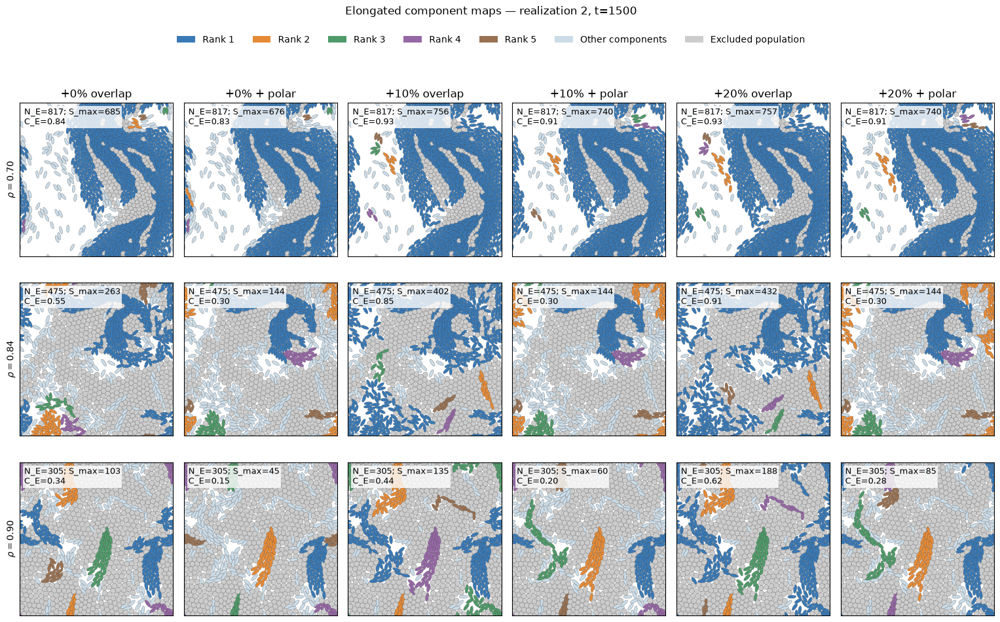

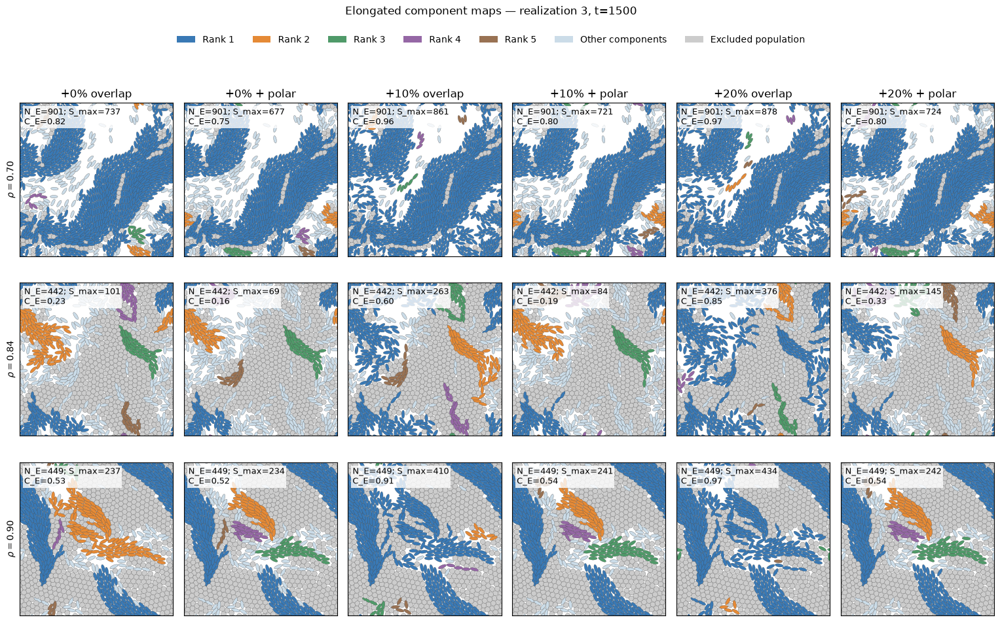

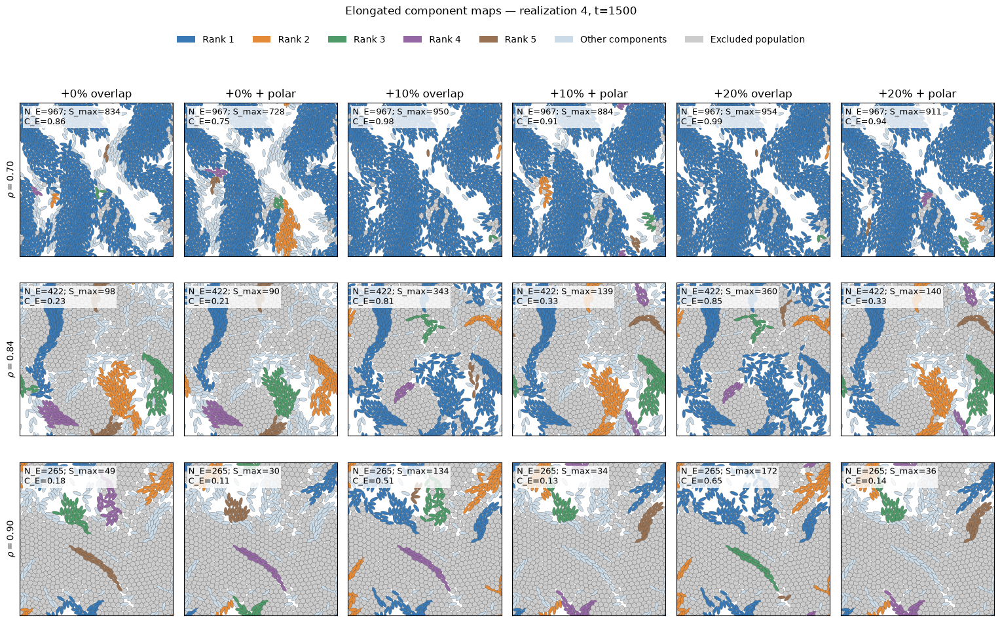

In [13]:
if PLOT_COMPONENT_MAPS:
    map_seeds = SEEDS if MAP_SEEDS is None else MAP_SEEDS
    map_densities = [rho for rho in MAP_DENSITIES if np.isclose(DENSITIES, rho).any()]
    map_populations = ["elongated", "round"] if PLOT_ROUND_COMPONENT_MAPS else ["elongated"]
    for population in map_populations:
        choices = list(product(RANGE_FACTORS, (False, True) if population == "elongated" else (False,)))
        symbol = POPULATION_SYMBOLS[population]
        for seed in map_seeds:
            fig, axes = plt.subplots(len(map_densities), len(choices),
                                      figsize=(3.2*len(choices), 3.1*len(map_densities)+1.5), squeeze=False)
            for row, rho in enumerate(map_densities):
                key = (LAMBDA_CORE, KAPPA, rho, seed, MAP_STEP)
                if key not in snapshot_paths:
                    for ax in axes[row]:
                        ax.text(.5, .5, "No run", ha="center", va="center", transform=ax.transAxes)
                        ax.set(xticks=[], yticks=[])
                    continue
                snapshot = read_snapshot(snapshot_paths[key])
                records, labels = analyze_connectivity(snapshot, with_labels=True)
                for col, (factor, polar_filter) in enumerate(choices):
                    record = next(r for r in records if r["population"] == population
                                  and r["range_factor"] == factor and r["polar_filter"] == polar_filter)
                    note = f"N_{symbol}={record['n_population']}; S_max={record['largest_size']}\nC_{symbol}={record['C']:.2f}"
                    draw_snapshot(axes[row, col], snapshot,
                                  facecolors=component_facecolors(labels[(population, factor, polar_filter)]), annotation=note)
                    if row == 0:
                        axes[row, col].set_title(f"+{100*(factor-1):.0f}%" + (" + polar" if polar_filter else " overlap"))
                    if col == 0:
                        axes[row, col].set_ylabel(rf"$\rho={rho:.2f}$")
            fig.suptitle(f"{POPULATION_NAMES[population]} component maps — realization {SEEDS.index(seed)+1}, t={MAP_STEP*DELTA_T:g}")
            handles = [Patch(facecolor=c, label=f"Rank {i+1}") for i, c in enumerate(COMPONENT_COLORS)]
            handles += [Patch(facecolor=SMALL_COMPONENT_COLOR, label="Other components"),
                        Patch(facecolor=ROUND_COLOR, label="Excluded population")]
            fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(.5, .95), ncol=min(7, len(choices)+1), frameon=False)
            fig.subplots_adjust(top=.85, wspace=.07, hspace=.10)
            finish_figure(fig, f"08_{population}_component_maps_seed_{seed}")

## 9. Deformation diagnostics and exports

Event rates below count accepted events per cell per unit time. Rejection fractions use the summed attempts as denominator, avoiding an unweighted average of interval ratios. A window with no attempts has an undefined rejection fraction. These diagnostics help distinguish reduced deformation activity from a change in how elongates organize.

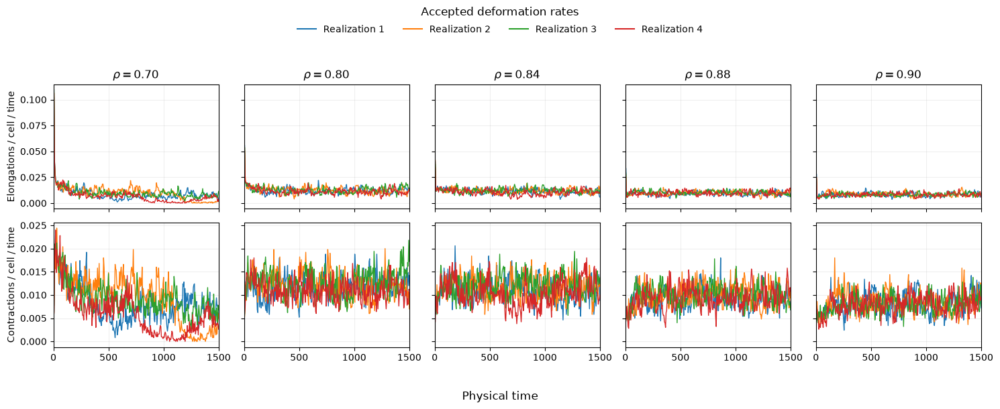

Figures: /home/usuario/Documentos/oncostreams/oncostreams_analysis_triangular/preliminar/kappa/refinement/figures
Tables: /home/usuario/Documentos/oncostreams/oncostreams_analysis_triangular/preliminar/kappa/refinement/analysis_tables


In [14]:
duration=deformation.number_of_steps*DELTA_T
for event in ["round_elongation_successes","contraction_events"]:
    deformation[event+"_rate"]=deformation[event]/(deformation.actual_N*duration)
time_panels(deformation,[("round_elongation_successes_rate","Elongations / cell / time"),
                          ("contraction_events_rate","Contractions / cell / time")],
            "09_deformation_rates","Accepted deformation rates")
event_windows=[]
for start,end in TIME_WINDOWS:
    part=deformation.loc[(deformation.time>start)&(deformation.time<=end)]
    result=part.groupby(RUN_KEYS,as_index=False)[["contraction_attempts","contraction_overlap_rejections","contraction_events","round_elongation_attempts","round_elongation_successes"]].sum()
    result["contraction_rejection_fraction"]=result.contraction_overlap_rejections/result.contraction_attempts.replace(0,np.nan)
    result["time_start"],result["time_end"]=start,end
    event_windows.append(result)
deformation_windows=pd.concat(event_windows,ignore_index=True)
for name,frame in [("validation",checks),("run_counts",run_counts),("order_window_summary",order_windows),
                   ("order_ensemble_summary",order_ensemble),("connectivity_ensemble_summary",connectivity_ensemble),
                   ("connectivity_window_summary",connectivity_windows),("deformation_window_summary",deformation_windows)]:
    frame.to_parquet(TABLE_DIR/f"{name}.parquet",index=False)
settings.update(time_windows=TIME_WINDOWS,densities=DENSITIES,seeds=SEEDS,
                kappa=KAPPA,lambda_core=LAMBDA_CORE,xi_safe=XI_SAFE,
                cluster_smoothing_time=CLUSTER_SMOOTHING_TIME, smoothing_used_for_statistics=False,
                ensemble_error_bars="sample_standard_deviation_between_realizations",
                expected_N=EXPECTED_N)
(TABLE_DIR/"analysis_settings.json").write_text(json.dumps(settings,indent=2))
print(f"Figures: {FIGURE_DIR.resolve()}\nTables: {TABLE_DIR.resolve()}")

## 10. Reading the results and planning the next simulations

- Compare successive windows before calling a curve stationary; smoothing cannot establish stationarity.
- Use the ensemble mean **and** seed dispersion to assess whether the density contrast is reproducible. The new runs and $\rho=0.75$ will help locate that contrast.
- Compare $f_X$, $C_X$ and $G_X$ for both populations. Round-cluster growth may partly follow the increasing number of round cells.
- Keep all three thresholds: sensitivity of a large component to a small range extension is scientifically relevant, not a reason to pick whichever cutoff makes a transition look strongest.
- Local polar links identify connected chains of similarly directed elongated cells, not necessarily globally aligned clusters or persistent currents.
- Connected-component size alone does not establish periodic wrapping, a thermodynamic transition, or its order. Abundance, alignment, and geometric connectivity need not share a single transition.
- A robust density-dependent organizational change is a useful candidate for further study. Before fitting exponents, verify integration and deformation-clock consistency, run long enough to assess drift, and then compare several system sizes and more densities around the candidate region.

**New exports:** `connectivity_ensemble_summary.parquet` stores mean, SD, SEM and contributing seed counts per density/window/graph; `run_counts.parquet` records the available sampling. The full connectivity table now includes `population`, generic `C`, `G`, and population-specific columns (`C_E`, `G_E`, `C_R`, `G_R`). All exported statistics use raw, unsmoothed series.